In [1]:
#EDSL has a cache directory that stores the responses from the LLM. Since we need new responses everytime, we need to clear the cache.    
import shutil
import os

# Path to the .edsl_cache directory
cache_dir = '.edsl_cache'

# Check if the directory exists
if os.path.exists(cache_dir):
    # Remove the directory and its contents
    shutil.rmtree(cache_dir)

In [2]:
from edsl import (
    QuestionFreeText,
    QuestionMultipleChoice,
    QuestionNumerical,
    Scenario,
    Survey,
    Agent,
    AgentList,
    Model,
)
import os
import random
import csv
import pandas as pd
import goodfire

In [3]:
# Initialize Goodfire client
client = goodfire.Client(os.getenv("GOODFIRE_API_KEY"))
# Create a Goodfire variant object instead of just using a string
base_variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

In [4]:
# Base Experiment Class
class SocialExperiment:
    def __init__(self, name, agents, model):
        self.name = name
        self.agents = agents
        self.model = model
        self.questions = []
        self.variant = goodfire.Variant(
            "meta-llama/Llama-3.3-70B-Instruct"
        )  # Initialize with base variant

    def setup(self):
        """Sets up the experiment by defining questions."""
        raise NotImplementedError

    def run(self, intervention=True):
        """Runs the experiment, optionally applying Goodfire interventions."""
        if intervention:
            self.model.parameters["controller"] = self.get_intervention()
            # For feature inspection, we need to apply the same controller to our variant
            controller_json = self.get_intervention()
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

            # Extract and apply features from controller JSON
            if "interventions" in controller_json:
                for intervention in controller_json["interventions"]:
                    if (
                        "features" in intervention
                        and "features" in intervention["features"]
                    ):
                        for feature_data in intervention["features"]["features"]:
                            # Create a feature object using feature search instead of direct creation
                            # This avoids needing to provide the index_in_sae
                            features = client.features.search(
                                feature_data["label"], model=self.variant, top_k=1
                            )
                            if features:
                                # Apply the feature with its value
                                self.variant.set(features[0], intervention["value"])
        else:
            self.model.parameters["controller"] = {}
            # Reset variant to base
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

        survey = Survey(self.questions)
        results = survey.by(self.agents).by(self.model).run(cache = False)
        return results

    def get_intervention(self):
        """Defines the Goodfire interventions for the experiment."""
        raise NotImplementedError

    def save_results(self, results, filename):
        """Saves results to a CSV file."""
        results.to_csv(filename)

    def print_results(self, results, experiment_name):
        """Prints formatted results for the experiment."""
        print(f"\n{experiment_name} Results:")
        print("--------------------")
        for question in self.questions:
            question_name = question.question_name
            ans = results.select(f"answer.{question_name}")
            com = results.select(f"comment.{question_name}_comment")
            print(f"\nQuestion: {question_name}")
            print(f"Answer: {ans}\nComment: {com}")

    def get_feature_activations(self, results, scenario_name, use_base_variant=False, activations_file=None):
        """Analyze feature activation for results and store in structured text file"""
        print(f"\n--- {scenario_name} Feature Activation ---")

        # Use base variant if requested (for baseline analysis)
        inspect_variant = base_variant if use_base_variant else self.variant

        # Get all question names from the result
        question_names = []
        for column in results.columns:
            if column.startswith("answer."):
                question_name = column.split(".")[1]
                if question_name not in question_names:
                    question_names.append(question_name)

        # Initialize activations data structure
        activations_data = {
            "scenario": scenario_name,
            "variant": "base" if use_base_variant else "intervention",
            "questions": {}
        }

        # Process each question
        for question_name in question_names:
            print(f"\nQuestion: {question_name}")

            # Get the user prompts and model responses
            try:
                # Select the relevant columns
                user_prompts = results.select(f"prompt.{question_name}_user_prompt")
                model_responses = results.select(
                    f"generated_tokens.{question_name}_generated_tokens"
                )

                # Convert to lists
                user_prompt_list = user_prompts.to_list()
                model_response_list = model_responses.to_list()

                # Check if we have data
                if user_prompt_list and model_response_list:
                    question_data = {
                        "total_responses": len(user_prompt_list),
                        "responses": []
                    }
                    
                    # Process ALL examples (no limit)
                    for i, (user_prompt, model_response) in enumerate(
                        zip(user_prompt_list, model_response_list)
                    ):
                        if user_prompt and model_response:
                            # Convert the user prompt from dict to string if necessary
                            if isinstance(user_prompt, dict) and "text" in user_prompt:
                                user_prompt = user_prompt["text"]

                            response_data = {
                                "response_id": i + 1,
                                "user_prompt": str(user_prompt),
                                "model_response": str(model_response),
                                "feature_activations": []
                            }

                            # Inspect feature activation
                            try:
                                inspector = client.features.inspect(
                                    [
                                        {"role": "user", "content": str(user_prompt)},
                                        {
                                            "role": "assistant",
                                            "content": str(model_response),
                                        },
                                    ],
                                    model=inspect_variant,  # Use the appropriate variant
                                )

                                # Store top activated features
                                for activation in inspector.top(k=10):
                                    response_data["feature_activations"].append({
                                        "feature_label": activation.feature.label,
                                        "activation_value": activation.activation
                                    })
                                    
                            except Exception as e:
                                response_data["error"] = f"Error analyzing features: {e}"
                            
                            question_data["responses"].append(response_data)
                    
                    activations_data["questions"][question_name] = question_data
                else:
                    print(f"No data found for question {question_name}")
            except Exception as e:
                print(f"Error processing data for question {question_name}: {e}")

        # Write activations to structured text file
        if activations_file:
            self._write_activations_to_file(activations_data, activations_file)

    def _write_activations_to_file(self, activations_data, filepath):
        """Write activations data to a structured text file"""
        with open(filepath, 'a', encoding='utf-8') as f:
            f.write(f"\n{'='*80}\n")
            f.write(f"SCENARIO: {activations_data['scenario']}\n")
            f.write(f"VARIANT: {activations_data['variant']}\n")
            f.write(f"{'='*80}\n\n")
            
            for question_name, question_data in activations_data['questions'].items():
                f.write(f"QUESTION: {question_name}\n")
                f.write(f"Total Responses: {question_data['total_responses']}\n")
                f.write(f"{'-'*60}\n\n")
                
                for response in question_data['responses']:
                    f.write(f"Response {response['response_id']}:\n")
                    f.write(f"User Prompt: {response['user_prompt']}\n")
                    f.write(f"Model Response: {response['model_response']}\n")
                    
                    if 'error' in response:
                        f.write(f"Error: {response['error']}\n")
                    else:
                        f.write("Top Feature Activations:\n")
                        for i, activation in enumerate(response['feature_activations'], 1):
                            f.write(f"  {i:2d}. {activation['feature_label']}: {activation['activation_value']:.6f}\n")
                    
                    f.write(f"\n{'-'*40}\n\n")
                
                f.write(f"\n{'='*60}\n\n")

In [5]:
# Safe vs. Risky Choice Experiment
class SafeRiskyChoice(SocialExperiment):
    def __init__(self, name, agents, model, risky_reward=100):
        super().__init__(name, agents, model)
        self.risky_reward = risky_reward
        
    def setup(self):
        self.questions = []
        choice_text = (
            "SAFE VS. RISKY CHOICE GAME\n\n"
            "You must choose between two options:\n"
            f"1. Safe Option: Guaranteed 50 tokens.\n"
            f"2. Risky Option: 50% chance of {self.risky_reward} tokens, 50% chance of 0 tokens.\n\n"
            "Which option do you choose?"
        )
        self.questions.append(
            QuestionMultipleChoice(
                question_name="safe_risky_choice",
                question_text=choice_text,
                question_options=[
                    "Safe Option",
                    "Risky Option",
                ],
            )
        )

    def get_intervention(self):
        return {
            "interventions": [
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "7f0e30ffb55c412cacd711909b11e5d0",
                                "label": "Willing to take risks or make sacrifices for a goal",
                                "index_in_sae": 184,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.7,
                },
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "b53742bf6f5040e0a8aeba37766335ff",
                                "label": "Executing potentially risky operations that require caution",
                                "index_in_sae": 4237,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.5,
                },
            ],
            "scopes": [],
            "name": "controller__44686645",
            "nonzero_strength_threshold": None,
            "min_nudge_entropy": None,
            "max_nudge_entropy": None,
        }

In [6]:
dummy_agents = AgentList(
    [
        Agent(name=f"Agent_{i}", traits={"subject_id": f"A{i}"}, instruction="")
        for i, age in enumerate(range(20, 60, 4), start=1)
    ]
)

model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")

In [7]:
def run_reward_experiments(agents, model, start=80, end=180, step=5):
    results = []
    
    # Create results directory
    results_dir = "mech_interp_games/safe_risky_choice/results"
    os.makedirs(results_dir, exist_ok=True)
    
    # Create activations file path
    activations_file = os.path.join(results_dir, "feature_activations.txt")
    
    # Clear the activations file at the start
    with open(activations_file, 'w', encoding='utf-8') as f:
        f.write("FEATURE ACTIVATIONS LOG\n")
        f.write("=" * 80 + "\n")
        f.write(f"Experiment: Safe vs. Risky Choice\n")
        f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 80 + "\n\n")
    
    for reward in range(start, end + step, step):
        print(f"\n--- Running experiment with risky reward: {reward} tokens ---")
        
        # Create experiment with current reward amount
        experiment_name = f"Safe vs. Risky Choice ({reward} tokens)"
        experiment = SafeRiskyChoice(experiment_name, agents, model, risky_reward=reward)
        experiment.setup()
        
        # Run with and without intervention
        print(f"\nRunning {experiment_name} without intervention...")
        baseline_results = experiment.run(intervention=False)
        
        print(f"\nRunning {experiment_name} with intervention...")
        intervention_results = experiment.run(intervention=True)
        
        # Save results
        baseline_filename = os.path.join(results_dir, f"safe_risky_baseline_{reward}.csv")
        intervention_filename = os.path.join(results_dir, f"safe_risky_intervention_{reward}.csv")
        
        experiment.save_results(baseline_results, baseline_filename)
        experiment.save_results(intervention_results, intervention_filename)
        
        # Print results
        experiment.print_results(baseline_results, f"{experiment_name} Baseline")
        experiment.print_results(intervention_results, f"{experiment_name} Intervention")
        
        # Track results for summary
        baseline_choices = baseline_results.select("answer.safe_risky_choice").to_list()
        intervention_choices = intervention_results.select("answer.safe_risky_choice").to_list()
        
        risky_percent_baseline = baseline_choices.count("Risky Option") / len(baseline_choices) * 100 if baseline_choices else 0
        risky_percent_intervention = intervention_choices.count("Risky Option") / len(intervention_choices) * 100 if intervention_choices else 0
        
        results.append({
            "reward": reward,
            "risky_percent_baseline": risky_percent_baseline,
            "risky_percent_intervention": risky_percent_intervention
        })

        # Get the prompts and responses for feature inspection
        print("\n=== Feature Activation Analysis ===")

        # Analyze baseline feature activation and store in file
        experiment.get_feature_activations(
            baseline_results, f"Baseline (Reward: {reward})", use_base_variant=True, activations_file=activations_file
        )

        # Analyze intervention feature activation and store in file
        experiment.get_feature_activations(
            intervention_results, f"Intervention (Reward: {reward})", use_base_variant=False, activations_file=activations_file
        )

    # Write summary to CSV
    summary_file = os.path.join(results_dir, "reward_experiment_summary.csv")
    with open(summary_file, 'w', newline='') as csvfile:
        fieldnames = ["reward", "risky_percent_baseline", "risky_percent_intervention"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    
    print(f"\nResults summary saved to {summary_file}")
    print(f"Feature activations saved to {activations_file}")
    return results



In [8]:
# Run the reward experiments
results_summary = run_reward_experiments(dummy_agents, model)


--- Running experiment with risky reward: 80 tokens ---

Running Safe vs. Risky Choice (80 tokens) without intervention...

Running Safe vs. Risky Choice (80 tokens) with intervention...

Safe vs. Risky Choice (80 tokens) Baseline Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['# I chose the Safe Option because it guarantees a certain amount of tokens, whereas the Risky Option has an equal chance of resulting in no tokens, which could be a significant loss.', '# I chose the Safe Option because it provides a guaranteed reward, whereas the Risky Option has a 50% chance of resulting in no tokens, which could be a significant loss. The potential gain of 30 extra tokens in the Risky Option is not enough to justify the risk of

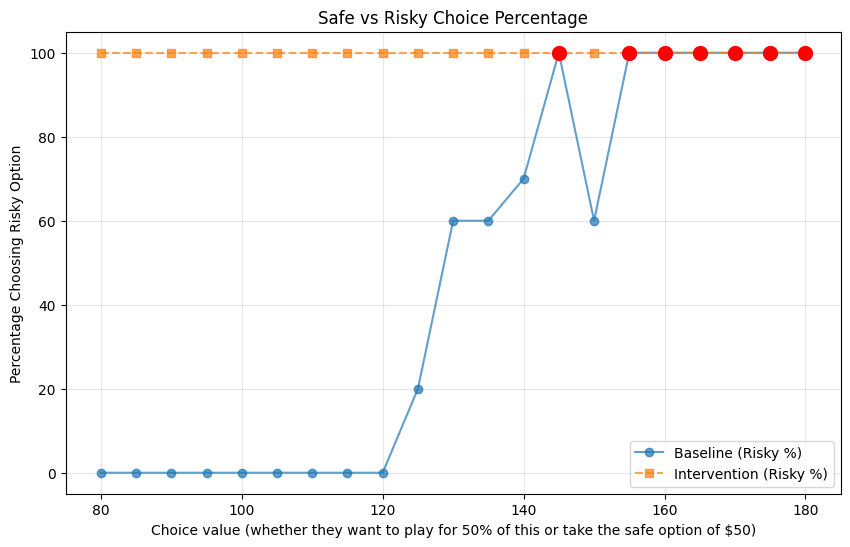

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_safe_risky_choices(directory):
    # Identify all relevant files
    files = sorted([f for f in os.listdir(directory) if f.startswith("safe_risky_") and f.endswith(".csv")])

    # Data storage
    baseline_data = {}
    intervention_data = {}

    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Compute percentage of "Safe Option" and "Risky Option"
        total_choices = len(df)
        safe_count = (df["answer.safe_risky_choice"] == "Safe Option").sum()
        risky_count = (df["answer.safe_risky_choice"] == "Risky Option").sum()
        
        safe_percentage = (safe_count / total_choices) * 100
        risky_percentage = (risky_count / total_choices) * 100
        
        # Extract iteration number from filename
        iteration = int(file.split("_")[-1].split(".")[0])
        
        # Store in appropriate dictionary
        if "baseline" in file:
            baseline_data[iteration] = risky_percentage
        elif "intervention" in file:
            intervention_data[iteration] = risky_percentage

    # Sort by iteration number
    baseline_data = dict(sorted(baseline_data.items()))
    intervention_data = dict(sorted(intervention_data.items()))

    # Plot results
    plt.figure(figsize=(10, 6))
    
    # Plot baseline with transparency
    plt.plot(baseline_data.keys(), baseline_data.values(), marker="o", linestyle="-", 
             label="Baseline (Risky %)", alpha=0.7)
    
    # Plot intervention with transparency and different color
    plt.plot(intervention_data.keys(), intervention_data.values(), marker="s", linestyle="--", 
             label="Intervention (Risky %)", alpha=0.7)

    # Add points with larger markers to highlight intersections
    for x in baseline_data.keys():
        if x in intervention_data:
            if abs(baseline_data[x] - intervention_data[x]) < 1:  # If values are very close
                plt.scatter(x, baseline_data[x], color='red', s=100, zorder=5,
                          label='Intersection' if x == min(baseline_data.keys()) else "")

    plt.xlabel("Choice value (whether they want to play for 50% of this or take the safe option of $50)")
    plt.ylabel("Percentage Choosing Risky Option")
    plt.title("Safe vs Risky Choice Percentage")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
plot_safe_risky_choices("/Users/arul/Desktop/my_repos/edsl_goodfire/edsl_games/safe_risky_choice/edsl_games/safe_risky_choice/results")
